In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
plt.rcParams.update({
    'font.size': 15,          # general font size
    'axes.titlesize': 15,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 12     # legend
})

l2_norm_by_dim


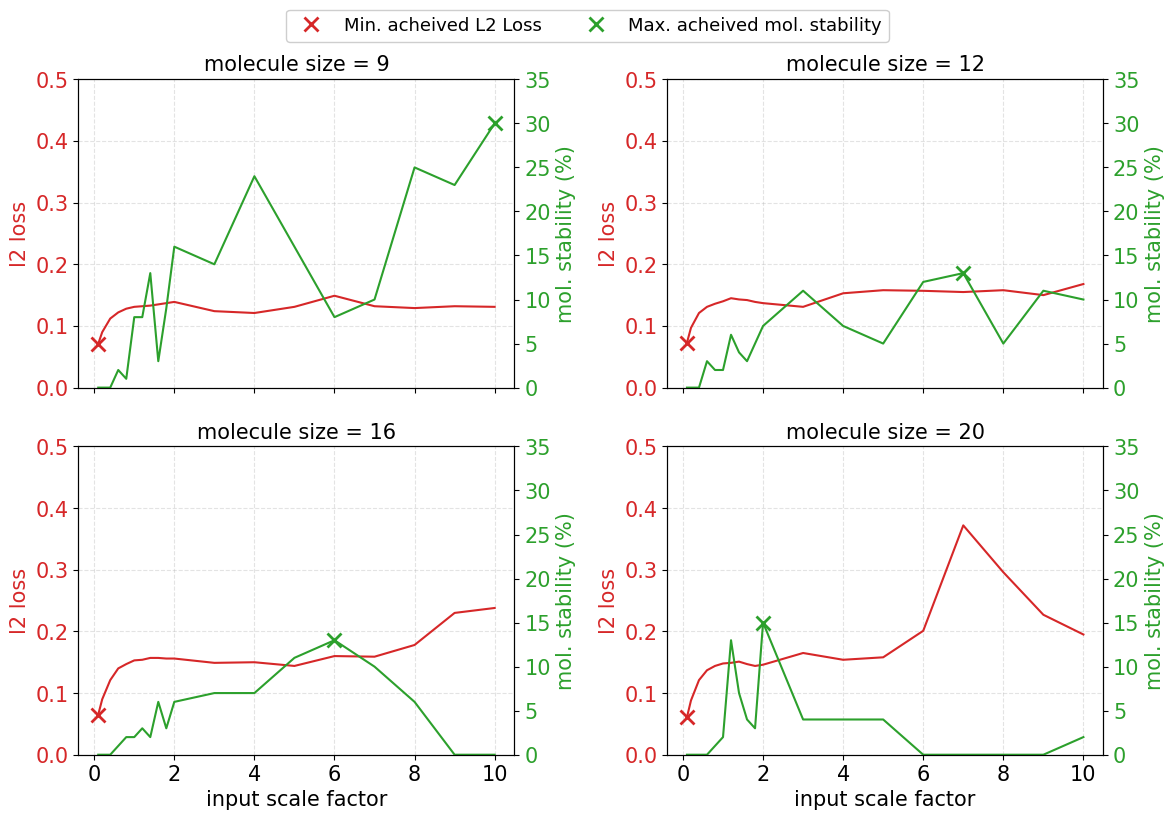

l2_norm_by_num_atoms


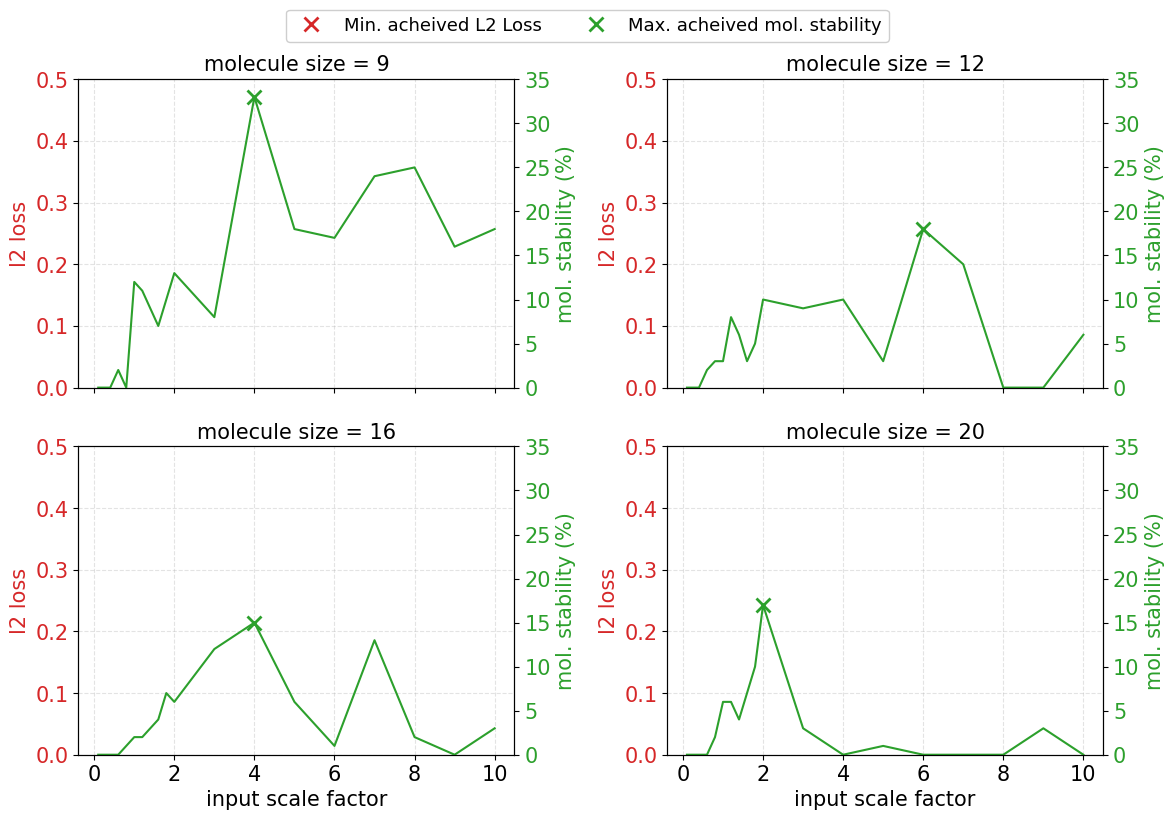

In [ ]:
df = pd.read_csv("input_scaling_evaluation_log_rq2.csv")

grouped = (
    df.groupby(
        ["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule", "diffusion_loss_type"], dropna=False,
    ).agg({"mol_stable": "mean", "test_l2": "mean"})
    .reset_index()
)

filter_values = sorted(grouped["filter_n_atoms"].dropna().unique()) 

mol_min, mol_max = grouped["mol_stable"].min(), grouped["mol_stable"].max()
test_min, test_max = grouped["test_l2"].min(), grouped["test_l2"].max()

for loss_value, loss_df in grouped.groupby("diffusion_loss_type"):
    print(loss_value)
    sub_df = grouped[grouped["diffusion_loss_type"] == loss_value].copy()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = loss_df[loss_df["filter_n_atoms"] == n_atoms].copy()
        sub_df = sub_df.sort_values("input_scale_factor").reset_index(drop=True)
        x = sub_df["input_scale_factor"].to_numpy()
        y_test = sub_df["test_l2"].to_numpy()
        y_mol = sub_df["mol_stable"].to_numpy()

        color_left = "tab:red"
        ax_left.plot(x, y_test, linestyle='-', color=color_left, label="Test L2")
        ax_left.set_ylabel("l2 loss", color=color_left)
        ax_left.tick_params(axis='y', labelcolor=color_left)
        ax_left.set_ylim(test_min, test_max)
        ax_left.set_title(f"molecule size = {n_atoms}")
        ax_left.grid(True, linestyle='--', alpha=0.35)
        idx_test_min = int(np.nanargmin(y_test))
        ax_left.plot(x[idx_test_min], y_test[idx_test_min], marker='x', markersize=10, markeredgewidth=2,
                    color=color_left, zorder=10, label="Min L2 Loss")

        ax_right = ax_left.twinx()
        color_right = "tab:green"
        ax_right.plot(x, y_mol, linestyle='-', color=color_right, label="mol. stability (%)")
        ax_right.set_ylabel("mol. stability (%)", color=color_right)
        ax_right.tick_params(axis='y', labelcolor=color_right)
        ax_right.set_ylim(bottom=0, top=mol_max + 2)

        idx_mol_max = int(np.nanargmax(y_mol))
        ax_right.plot(x[idx_mol_max], y_mol[idx_mol_max], marker='x', markersize=10, markeredgewidth=2,
                      color=color_right, zorder=10, label="Max mol_stable")

        if i >= 2:
            ax_left.set_xlabel("input scale factor")

    plt.tight_layout()

    # --- GLOBAL LEGEND FOR MARKERS (X and O) ---
    legend_elements = [
        Line2D([0], [0], marker='x', color='tab:red', linestyle='none',
               markersize=10, markeredgewidth=2, label="Min. acheived L2 Loss"),
    
        Line2D([0], [0], marker='x', color='tab:green', linestyle='none',
               markersize=10, markeredgewidth=2, label="Max. acheived mol. stability"),
    ]
    
    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=2,
        framealpha=0.95,
        bbox_to_anchor=(0.5, 1.04),
    )

    plt.show()


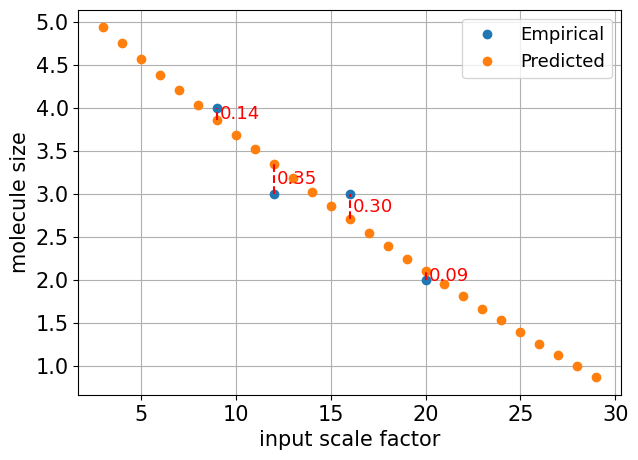

In [15]:
# cosine

x1 = [9, 12, 16, 20]
y1 = [4.0, 3.0, 3.0, 2.0]

x2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
y2 = [4.93553191, 4.74970213, 4.56621277, 4.38506383, 4.20625532, 4.02978723, 
      3.85565957, 3.68387234, 3.51442553, 3.34731915, 3.18255319, 3.02012766,
      2.86004255, 2.70229787, 2.54689362, 2.39382979, 2.24310638, 2.09472340,
      1.94868085, 1.80497872, 1.66361702, 1.52459574, 1.38791489, 1.25357447,
      1.12157447, 0.99191489, 0.86459574]

plt.figure(figsize=(7,5))

plt.plot(x1, y1, 'o', label="Empirical", markersize=6)
plt.plot(x2, y2, 'o', label="Predicted", markersize=6)

# ---- Add extrapolation error lines ----
for x in x1:
    if x in x2:
        y_emp = y1[x1.index(x)]
        y_pred = y2[x2.index(x)]

        plt.vlines(
            x,
            min(y_emp, y_pred),
            max(y_emp, y_pred),
            colors='red',
            linestyles='--',
            linewidth=1.5,
            label=None
        )

        plt.text(
            x + 0.15,
            (y_emp + y_pred) / 2,
            f"{abs(y_emp - y_pred):.2f}",
            color='red',
            fontsize=13,
            va='center'
        )

plt.xlabel("input scale factor")
plt.ylabel("molecule size")
plt.grid(True)
plt.legend()

plt.show()


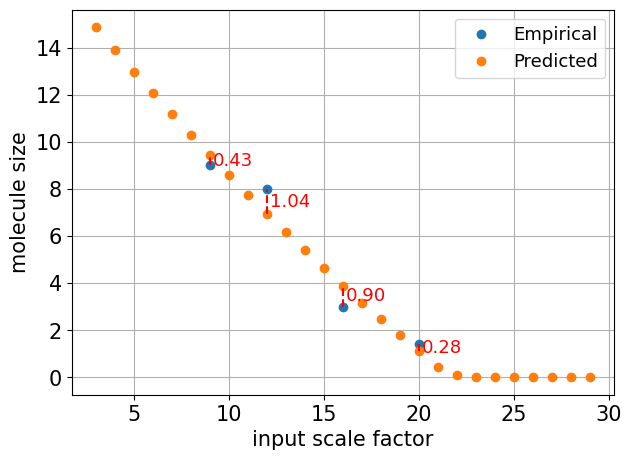

In [16]:
# quadratic

# First set
x1 = [9, 12, 16, 20]
y1 = [9.0, 8.0, 3.0, 1.4]

# Second set
x2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 
      21, 22, 23, 24, 25, 26, 27, 28, 29]

y2 = [14.86370213, 13.91504681, 12.98388085, 12.07020426, 11.17401702,
      10.29531915,  9.43411064,  8.59039149,  7.7641617 ,  6.95542128,
       6.16417021,  5.39040851,  4.63413617,  3.89535319,  3.17405957,
       2.47025532,  1.78394043,  1.11511489,  0.46377872,  0.1        ,
       0.01        , 0.01        ,  0.01        ,  0.01        , 0.01        ,
       0.01        ,  0.01       ]

plt.figure(figsize=(7,5))

plt.plot(x1, y1, 'o', label="Empirical", markersize=6)
plt.plot(x2, y2, 'o', label="Predicted", markersize=6)

# ---- Add extrapolation error lines ----
for x in x1:
    if x in x2:
        y_emp = y1[x1.index(x)]
        y_pred = y2[x2.index(x)]

        plt.vlines(
            x,
            min(y_emp, y_pred),
            max(y_emp, y_pred),
            colors='red',
            linestyles='--',
            linewidth=1.5,
            label=None
        )

        plt.text(
            x + 0.15,
            (y_emp + y_pred) / 2,
            f"{abs(y_emp - y_pred):.2f}",
            color='red',
            fontsize=13,
            va='center'
        )

plt.xlabel("input scale factor")
plt.ylabel("molecule size")
plt.grid(True)
plt.legend()

plt.show()
